# FFT from Pendulum Experiment
## Use zero padding to extend data

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from scipy.signal import chirp, spectrogram, windows
from scipy.fftpack import fft, ifft, fftfreq, fftshift, ifftshift
from scipy.io.wavfile import write 


In [4]:
from numpy import genfromtxt
file_name = 'data/data_pdata5.csv'
data = genfromtxt(file_name, delimiter=',', comments='%')
print("Loaded local recorded data")

Loaded local recorded data


In [5]:
# remove some initial poor data
Nstart = 175
L1 = slice(Nstart,len(data)) # only use some of the data
L = len(data) - Nstart

t = (data[L1,0] - data[L1.start,0])/1e3
x1 = data[L1,1]/4500 # rescale
x1 -= np.mean(x1) # remove non-zero average

T = np.mean(np.diff(t))
Fs = 1/T

In [6]:
n = int(2**np.ceil(np.log2(L)))

X1 = fft(x1,n) # pad to n >= L pts and find FFT
X1_mag = np.abs(X1)/n # scaling
X1_mag_plot = fftshift(X1_mag) # find magnitude of FFT
f = fftfreq(n, 1/Fs)
f_plot = fftshift(f)

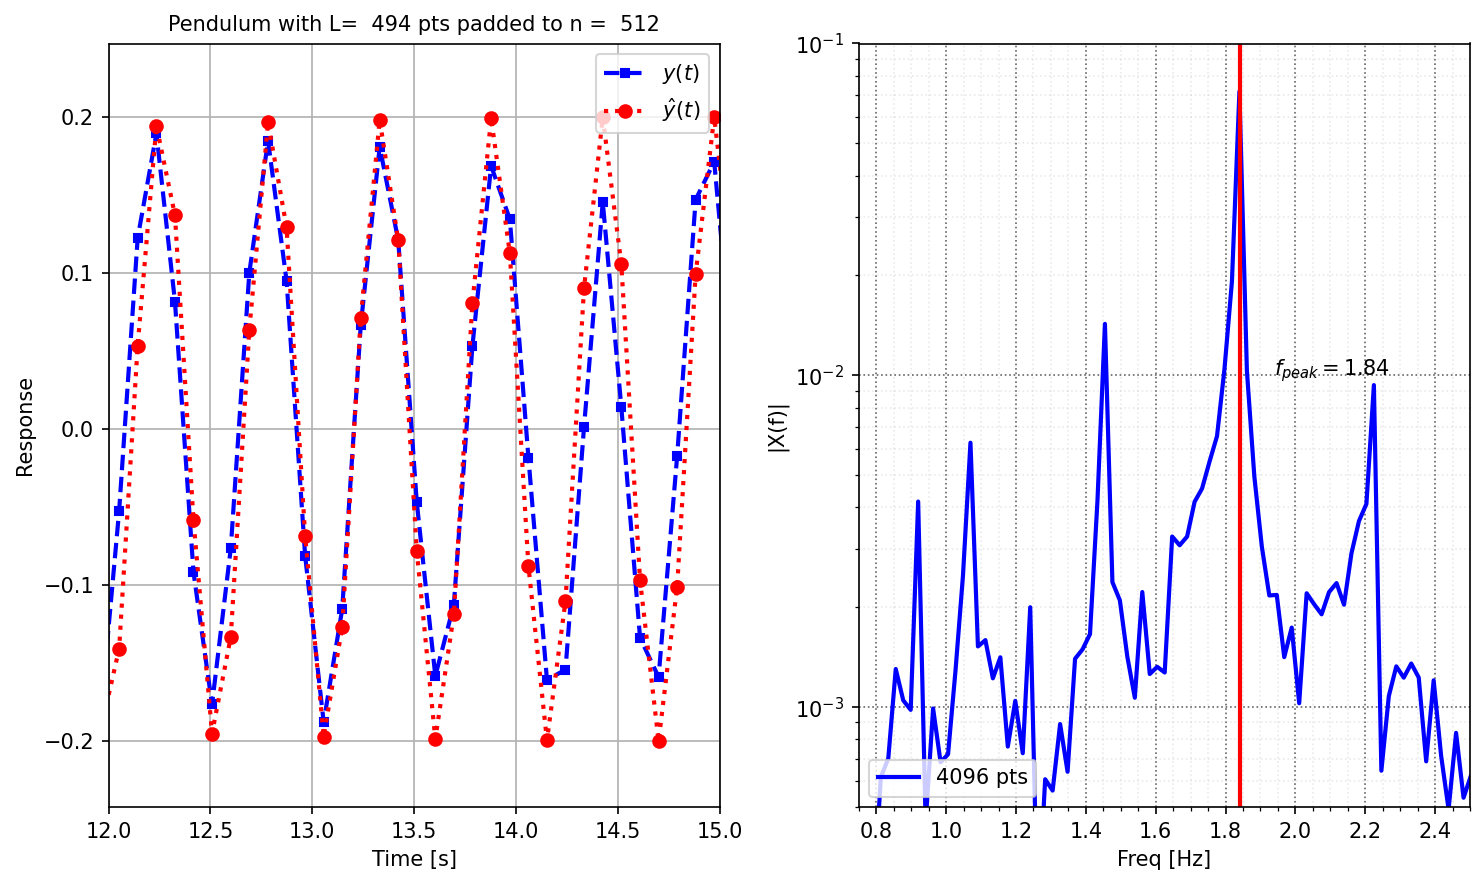

In [7]:
# Predictions based on observations
f_pred = 1.84
ph_pred = 1.4*np.pi
amp_pred = 0.2

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,6), dpi=150)
ax1.plot(t,x1,'bs--',ms=4,label='$y(t)$')
ax1.plot(t,amp_pred*np.sin(2*np.pi*f_pred*t + ph_pred),'ro:',label='$\hat y(t)$')
ax1.set_ylabel('Response')
ax1.set_xlabel('Time [s]')
ax1.legend()
ax1.set_title(f"Pendulum with {L= : 4d} pts padded to {n = :4d}")
ax1.set_xlim([12, 15])

f_peak = f[np.argmax(X1_mag)]
ax2.semilogy(f_plot, X1_mag_plot,'b-',label='4096 pts')
ax2.axvline(f_pred,color='r')
ax2.text(f_pred + 0.1,.01,'$f_{peak}=$'+str(np.round(f[np.argmax(X1_mag)],2)))
ax2.set_xlim([.75, 2.5])
ax2.set_ylim([5e-4, 0.1])
ax2.legend(loc=3)
ax2.set_xlabel('Freq [Hz]')
ax2.set_ylabel('|X(f)|')
bm.nicegrid()
fig.savefig('./figs/T8_ex10_1.pdf',format='pdf', dpi=300)
plt.show()